### Directional Coupler 2×2 (4‑port)

Test notebook for `DirectionalCoupler2D` with excitation from any port and full 4‑port S‑parameter readout.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import meep as mp

import sys
import importlib
sys.path.append('../..')

import directional_coupler as dc_mod
importlib.reload(dc_mod)
from directional_coupler import DirectionalCoupler2D

from FDTD.utils import (
    build_device_overlay_masks,
    plot_overlay_masks,
    DEFAULT_OVERLAY_COLORS,
    legend_handles_from_masks,
)

np.set_printoptions(precision=4, suppress=True)

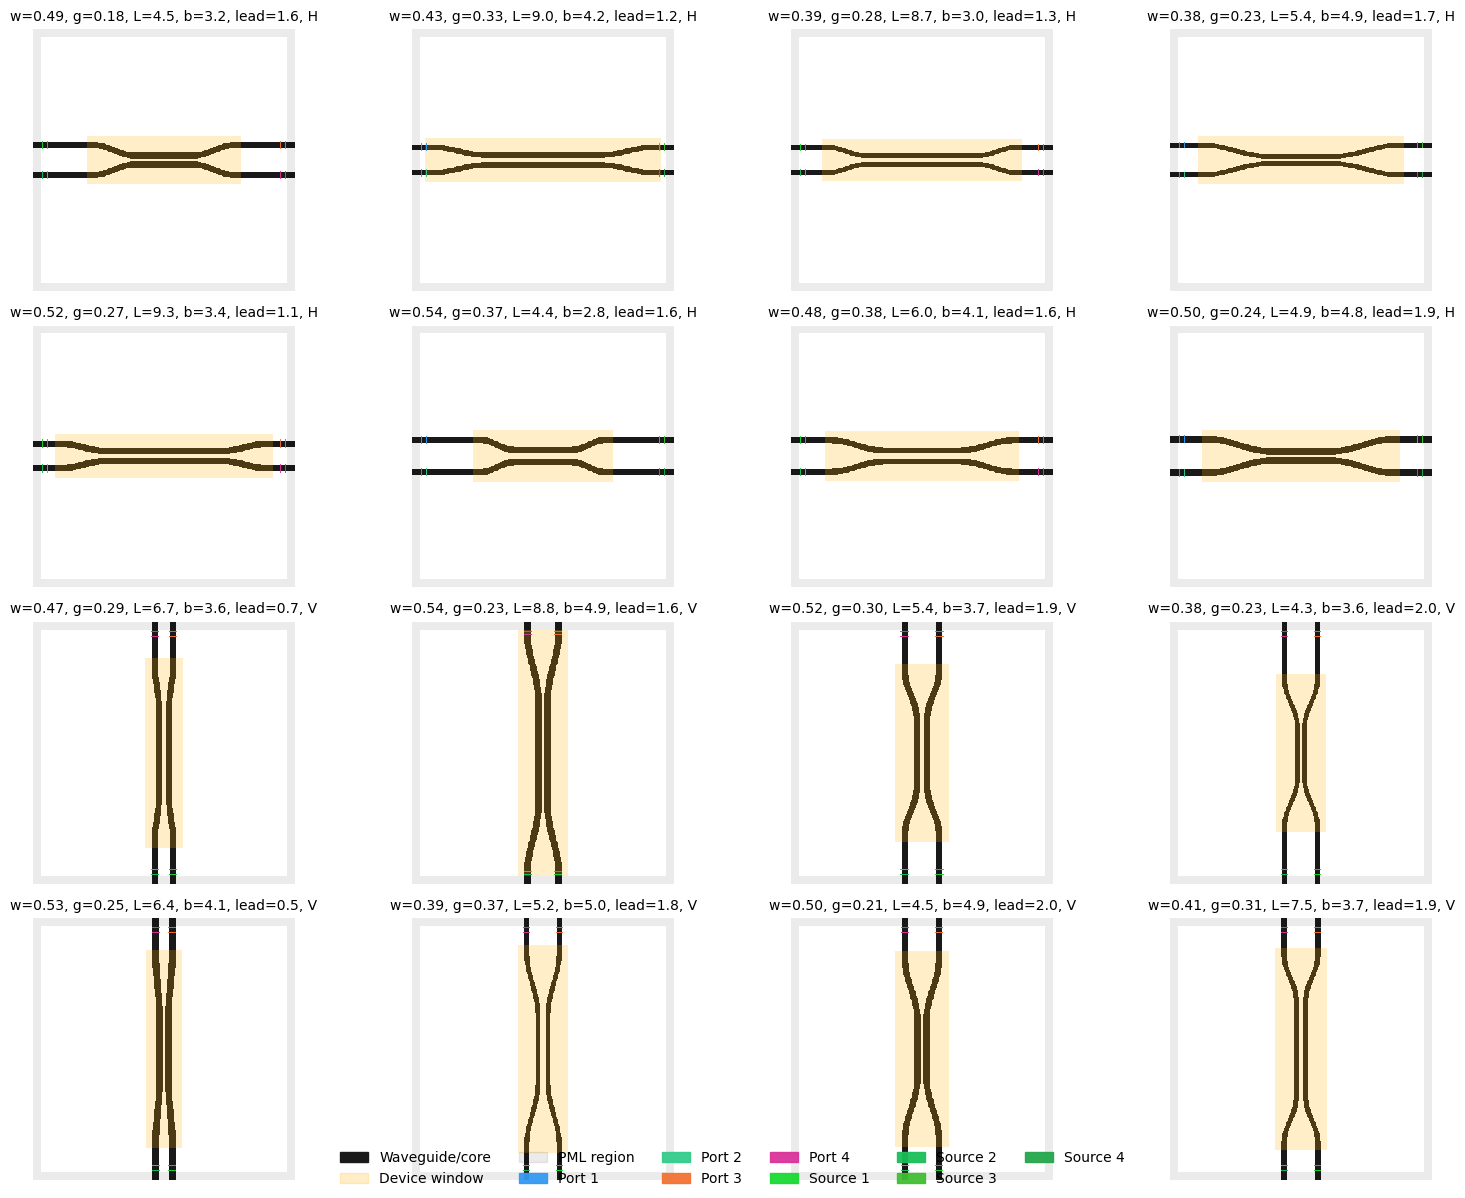

In [2]:
# =========================
# Cell 2: Geometry Sweep (16 geos) using overlays
# =========================
rng = np.random.default_rng(0)
widths  = rng.uniform(0.38, 0.55, 16)
lams    = rng.uniform(1.45, 1.60, 16)
gaps    = rng.uniform(0.15, 0.40, 16)
lengths = rng.uniform(4.0, 10, 16)
bends   = rng.uniform(2.5, 5.0, 16)
lead_gaps = rng.uniform(0.5, 2.0, 16)

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for i in range(16):
    # First 8 horizontal (left→right), last 8 vertical (top→bottom)
    orientation = "horizontal" if i < 8 else "vertical"
    
    dev = DirectionalCoupler2D(
        wg_width_um=float(widths[i]),
        wavelength_um=float(lams[i]),
        gap_um=float(gaps[i]),
        wg_length_um=float(lengths[i]),
        bend_length_um=float(bends[i]),
        lead_extra_gap_um=float(lead_gaps[i]),
        orientation=orientation,
    )

    masks = build_device_overlay_masks(dev)

    ax = axes[i]
    plot_overlay_masks(
        ax,
        masks,
        colors=DEFAULT_OVERLAY_COLORS,
        title=(
            f"w={widths[i]:.2f}, g={gaps[i]:.2f}, L={lengths[i]:.1f}, "
            f"b={bends[i]:.1f}, lead={lead_gaps[i]:.1f}, {orientation[0].upper()}"
        ),
    )

handles = legend_handles_from_masks(masks, colors=DEFAULT_OVERLAY_COLORS)
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False)
plt.tight_layout()
plt.show()


In [3]:
# =========================
# Cell 3: S-param Calibration (dir_plus/dir_minus discovery)
# =========================
import numpy as np
import meep as mp

from FDTD.utils import get_mode_alpha_2dir, pick_in_out_from_alpha

toward = {1: +1, 2: +1, 3: -1, 4: -1}

lead_gap = 1.0

dev = DirectionalCoupler2D(
    wg_width_um=0.45,
    gap_um=0.2,
    wg_length_um=8.0,
    bend_length_um=2.0,
    lead_extra_gap_um=lead_gap,
    wavelength_um=1.55,
)

lam = dev.wavelength_um
fcen = 1.0 / lam
df_source = 0.1 * fcen

sources = [
    mp.EigenModeSource(
        src=mp.GaussianSource(fcen, fwidth=df_source),
        volume=dev.src_1,
        eig_band=1,
        eig_parity=mp.NO_PARITY,
        eig_match_freq=True,
        eig_kpoint=mp.Vector3(+1, 0, 0),
    )
]

sim = mp.Simulation(
    cell_size=dev.cell,
    resolution=dev.resolution,
    boundary_layers=[mp.PML(dev.dpml)],
    geometry=dev.geometry,
    default_material=dev.clad_medium,
    sources=sources,
)

m1 = sim.add_mode_monitor(fcen, 0, 1, mp.ModeRegion(volume=dev.port_1, direction=mp.X))
m2 = sim.add_mode_monitor(fcen, 0, 1, mp.ModeRegion(volume=dev.port_2, direction=mp.X))
m3 = sim.add_mode_monitor(fcen, 0, 1, mp.ModeRegion(volume=dev.port_3, direction=mp.X))
m4 = sim.add_mode_monitor(fcen, 0, 1, mp.ModeRegion(volume=dev.port_4, direction=mp.X))

sim.run(until_after_sources=mp.stop_when_dft_decayed(tol=1e-6))

alpha1 = np.asarray(get_mode_alpha_2dir(sim, m1, band=1, eig_parity=mp.NO_PARITY))
alpha3 = np.asarray(get_mode_alpha_2dir(sim, m3, band=1, eig_parity=mp.NO_PARITY))
if alpha1.ndim == 2:
    alpha1 = alpha1[0]
if alpha3.ndim == 2:
    alpha3 = alpha3[0]

print("alpha1 (port1) =", alpha1)
print("alpha3 (port3) =", alpha3)

dir_plus = int(np.argmax(np.abs(alpha1)))
dir_minus = 1 - dir_plus
print("dir_plus =", dir_plus, "dir_minus =", dir_minus)

# Sanity: input port (1) should have strong incoming, output port (3) strong outgoing
# (port 2/4 may have weaker coupling depending on geometry)
a1_in, b1_out = pick_in_out_from_alpha(alpha1, toward[1], dir_plus=dir_plus, dir_minus=dir_minus)
a3_in, b3_out = pick_in_out_from_alpha(alpha3, toward[3], dir_plus=dir_plus, dir_minus=dir_minus)
print("sanity: a1_in (should be large) =", a1_in)
print("sanity: b1_out (should be small) =", b1_out)
print("sanity: a3_in (should be small) =", a3_in)
print("sanity: b3_out (should be large) =", b3_out)

sim.reset_meep()

DIR_PLUS = dir_plus
DIR_MINUS = dir_minus


-----------
Initializing structure...
time for choose_chunkdivision = 0.0152161 s
Working in 2D dimensions.
Computational cell is 20.5 x 20.5 x 0 with resolution 20
     block, center = (0,0.325,0)
          size (8,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (0,-0.325,0)
          size (8,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (-5.96875,0.824699,0)
          size (0.065625,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (-5.90625,0.822294,0)
          size (0.065625,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (-5.84375,0.817508,0)
          size (0.065625,0.45,1e+20)
    

MPB solved for frequency_1(1,0,0) = 0.466246 after 13 iters
MPB solved for frequency_1(1.38708,0,0) = 0.644275 after 6 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 1 iters
on time step 356 (time=8.9), 0.0112694 s/step
on time step 887 (time=22.175), 0.00753603 s/step
on time step 1222 (time=30.55), 0.0119864 s/step
on time step 1703 (time=42.575), 0.00832309 s/step
on time step 2136 (time=53.4), 0.00924509 s/step
on time step 2734 (time=68.35), 0.00669375 s/step
on time step 3255 (time=81.375), 0.00770656 s/step
on time step 3828 (time=95.7), 0.00698703 s/step
on time step 4251 (time=106.275), 0.00950709 s/step
on time step 4819 (time=120.475), 0.00704772 s/step
on time step 5252 (time=131.3), 0.0092415 s/step
on time step 5695 (time=142.375), 0.00904219 s/step
on time step 6082 (time=152.05), 0.01039 s/step
on time step 6654 (time=166.35), 0.00699347 s/step
on time step 7135 (time=178.375), 0.00832117 s

run 0 finished at t = 195.3 (7812 timesteps)
MPB solved for frequency_1(1.4664,0,0) = 0.680527 after 16 iters
MPB solved for frequency_1(1.38893,0,0) = 0.645123 after 5 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.389013,-0.000000,0.000000)


MPB solved for frequency_1(1.4664,0,0) = 0.680527 after 16 iters
MPB solved for frequency_1(1.38893,0,0) = 0.645123 after 5 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.389013,-0.000000,0.000000)
alpha1 (port1) = [-13.8115-1.173j   -0.3495-0.2081j]
alpha3 (port3) = [1.2516+1.8841j 0.0138+0.0199j]
dir_plus = 0 dir_minus = 1
sanity: a1_in (should be large) = (-13.811501672696835-1.1730404451298668j)
sanity: b1_out (should be small) = (-0.3494999008090964-0.20808972187370234j)
sanity: a3_in (should be small) = (0.013777126016106834+0.019901835815331885j)
sanity: b3_out (should be large) = (1.2516395871972792+1.8841497021669753j)


-----------
Initializing structure...
time for choose_chunkdivision = 0.000962973 s
Working in 2D dimensions.
Computational cell is 20.5 x 20.5 x 0 with resolution 20
     block, center = (0,0.325,0)
          size (8,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (0,-0.325,0)
          size (8,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (-9.02031,1.3244,0)
          size (0.167344,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (-8.86094,1.31959,0)
          size (0.167344,0.45,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (5.16615,5.16615,5.16615)
     block, center = (-8.70156,1.31002,0)
          size (0.167344,0.45,1e+20)
      

MPB solved for frequency_1(1,0,0) = 0.466246 after 13 iters
MPB solved for frequency_1(1.38708,0,0) = 0.644275 after 6 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 1 iters
on time step 450 (time=11.25), 0.00889652 s/step
on time step 832 (time=20.8), 0.0104857 s/step
on time step 1315 (time=32.875), 0.00829578 s/step
on time step 1698 (time=42.45), 0.0104658 s/step
on time step 1973 (time=49.325), 0.0145573 s/step
on time step 2369 (time=59.225), 0.0101086 s/step
on time step 2736 (time=68.4), 0.0109259 s/step
on time step 3001 (time=75.025), 0.0151146 s/step
on time step 3361 (time=84.025), 0.0111276 s/step
on time step 3728 (time=93.2), 0.0109026 s/step
on time step 4122 (time=103.05), 0.0101934 s/step
on time step 4532 (time=113.3), 0.00977584 s/step
on time step 5021 (time=125.525), 0.0081876 s/step
on time step 5408 (time=135.2), 0.0103564 s/step
on time step 5821 (time=145.525), 0.00969121 s/step
o

run 0 finished at t = 226.8 (9072 timesteps)
MPB solved for frequency_1(1.4664,0,0) = 0.680527 after 16 iters
MPB solved for frequency_1(1.38893,0,0) = 0.645123 after 5 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.389013,-0.000000,0.000000)


MPB solved for frequency_1(1.4664,0,0) = 0.680527 after 16 iters
MPB solved for frequency_1(1.38893,0,0) = 0.645123 after 5 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.389013,-0.000000,0.000000)


MPB solved for frequency_1(1.4664,0,0) = 0.680527 after 16 iters
MPB solved for frequency_1(1.38893,0,0) = 0.645123 after 5 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.389013,-0.000000,0.000000)


MPB solved for frequency_1(1.4664,0,0) = 0.680527 after 16 iters
MPB solved for frequency_1(1.38893,0,0) = 0.645123 after 5 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.38901,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.389013,-0.000000,0.000000)
Input port 1: |S1|=0.0285 |S2|=0.0152 |S3|=0.4056 |S4|=0.8472


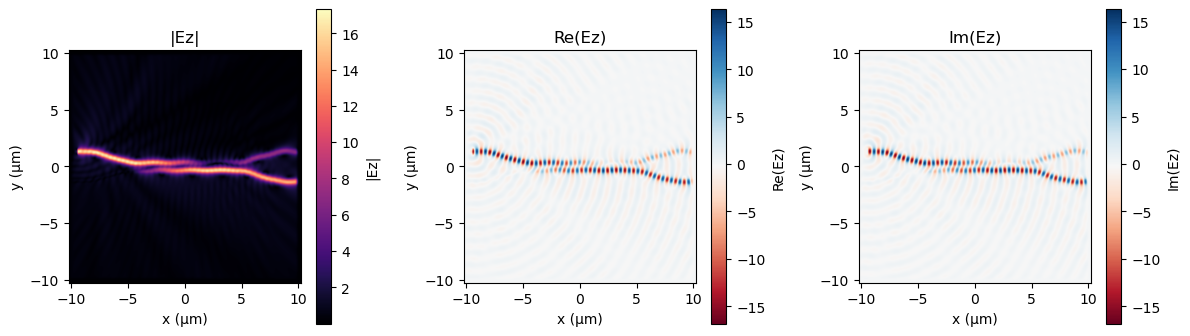

In [4]:
# =========================
# Cell 3: Single-frequency S-params + field plot
# =========================

def print_sparams(S, input_port):
    vals = [abs(S[(k, input_port)]) for k in (1, 2, 3, 4)]
    print(f"Input port {input_port}: |S1|={vals[0]:.4f} |S2|={vals[1]:.4f} |S3|={vals[2]:.4f} |S4|={vals[3]:.4f}")


bend_len = 6
lead_gap = 2.0

dev = DirectionalCoupler2D(
    wg_width_um=0.45,
    gap_um=0.2,
    wg_length_um=8.0,
    bend_length_um=bend_len,
    lead_extra_gap_um=lead_gap,
    wavelength_um=1.55,
)

eps_mid, Ez_mid, Hx_mid, Hy_mid, S, (cell_x, cell_y) = dev.run_sim(input_port=1)
print_sparams(S, 1)

extent = [-0.5 * cell_x, 0.5 * cell_x, -0.5 * cell_y, 0.5 * cell_y]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
plots = [
    ("|Ez|", np.abs(Ez_mid), "magma"),
    ("Re(Ez)", np.real(Ez_mid), "RdBu"),
    ("Im(Ez)", np.imag(Ez_mid), "RdBu"),
]

for ax, (title, data, cmap) in zip(axes, plots):
    im = ax.imshow(data, origin="lower", cmap=cmap, extent=extent, aspect="equal")
    ax.set_title(title)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    plt.colorbar(im, ax=ax, shrink=0.85, label=title)

plt.tight_layout()
plt.show()


In [ ]:
# =========================
# Cell 4: Excite each port and report S-matrix magnitudes
# =========================

def srow(dev, input_port):
    _, _, _, _, S, _ = dev.run_sim(input_port=input_port)
    return [abs(S[(k, input_port)]) for k in (1, 2, 3, 4)]


bend_len = 2.0
lead_gap = 1.0

dev = DirectionalCoupler2D(
    wg_width_um=0.45,
    gap_um=0.25,
    wg_length_um=10.0,
    bend_length_um=bend_len,
    lead_extra_gap_um=lead_gap,
    wavelength_um=1.55,
)

Smat = []
for pin in (1, 2, 3, 4):
    row = srow(dev, pin)
    Smat.append(row)
    print(f"Input {pin}: {row}")

Smat = np.array(Smat)
plt.figure(figsize=(4.5, 3.8))
plt.imshow(Smat, origin="lower", cmap="viridis")
plt.colorbar(label="|S| magnitude")
plt.xticks([0, 1, 2, 3], ["1", "2", "3", "4"])
plt.yticks([0, 1, 2, 3], ["1", "2", "3", "4"])
plt.xlabel("Output port")
plt.ylabel("Input port")
plt.title("|S_ij| (single-frequency)")
plt.show()


In [ ]:
# =========================
# Cell 6: Multi-port excitation visualization
# =========================
# Simulate and visualize field patterns for all 4 port excitations

bend_len = 4.0
lead_gap = 1.5

dev = DirectionalCoupler2D(
    wg_width_um=0.45,
    gap_um=0.20,
    wg_length_um=8.0,
    bend_length_um=bend_len,
    lead_extra_gap_um=lead_gap,
    wavelength_um=1.55,
)

fig, axes = plt.subplots(4, 3, figsize=(14, 16))

port_labels = {
    1: "Port 1 (top-left)",
    2: "Port 2 (bottom-left)",
    3: "Port 3 (top-right)",
    4: "Port 4 (bottom-right)",
}

results = {}
for i, input_port in enumerate([1, 2, 3, 4]):
    eps, Ez, Hx, Hy, S, (cell_x, cell_y) = dev.run_sim(input_port=input_port)
    results[input_port] = {"eps": eps, "Ez": Ez, "S": S, "cell_x": cell_x, "cell_y": cell_y}
    
    extent = [-0.5 * cell_x, 0.5 * cell_x, -0.5 * cell_y, 0.5 * cell_y]
    
    # |Ez|
    im0 = axes[i, 0].imshow(np.abs(Ez), origin="lower", cmap="magma", extent=extent, aspect="equal")
    axes[i, 0].set_title(f"{port_labels[input_port]}\n|Ez|")
    axes[i, 0].set_xlabel("x (µm)")
    axes[i, 0].set_ylabel("y (µm)")
    plt.colorbar(im0, ax=axes[i, 0], shrink=0.7)
    
    # Re(Ez)
    vmax = np.max(np.abs(np.real(Ez)))
    im1 = axes[i, 1].imshow(np.real(Ez), origin="lower", cmap="RdBu", extent=extent, 
                            aspect="equal", vmin=-vmax, vmax=vmax)
    axes[i, 1].set_title(f"Re(Ez)")
    axes[i, 1].set_xlabel("x (µm)")
    axes[i, 1].set_ylabel("y (µm)")
    plt.colorbar(im1, ax=axes[i, 1], shrink=0.7)
    
    # Im(Ez)
    vmax = np.max(np.abs(np.imag(Ez)))
    im2 = axes[i, 2].imshow(np.imag(Ez), origin="lower", cmap="RdBu", extent=extent,
                            aspect="equal", vmin=-vmax, vmax=vmax)
    axes[i, 2].set_title(f"Im(Ez)")
    axes[i, 2].set_xlabel("x (µm)")
    axes[i, 2].set_ylabel("y (µm)")
    plt.colorbar(im2, ax=axes[i, 2], shrink=0.7)

plt.suptitle("Directional Coupler: Field patterns for each port excitation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print S-parameters for each excitation
print("\n" + "="*70)
print("S-parameters summary:")
print("="*70)
for input_port in [1, 2, 3, 4]:
    S = results[input_port]["S"]
    mags = [abs(S[(p, input_port)]) for p in [1, 2, 3, 4]]
    powers = [m**2 for m in mags]
    print(f"\nInput port {input_port} ({port_labels[input_port].split('(')[1][:-1]}):")
    print(f"  |S1{input_port}| = {mags[0]:.4f}  |S2{input_port}| = {mags[1]:.4f}  |S3{input_port}| = {mags[2]:.4f}  |S4{input_port}| = {mags[3]:.4f}")
    print(f"  Power: {' + '.join([f'{p:.4f}' for p in powers])} = {sum(powers):.4f}")